# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [4]:
df=pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.shape




(150, 6)

In [7]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [8]:
df.info


<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  Iris-virginica  
146  Iris-virginica  
147  Iris-virginica  
148  Iris-virginica  
149  Iris-virginica  

[150 rows x 6 columns]>

In [9]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


# Remove Unnecessary Column

In [12]:
df.drop('Id',axis=1,inplace=True)

# Split Features and Target

In [13]:
X = df.drop('Species', axis=1)

y = df['Species']

# Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [16]:
log_predictions = log_model.predict(X_test)

# Accuracy Score

In [17]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(
    y_test,
    log_predictions
)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 1.0


# KNN Model

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


# Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


# Model Comparison Table

In [20]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],

    'Accuracy': [
        log_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN,1.0
2,Random Forest,1.0


# Confusion Matrix

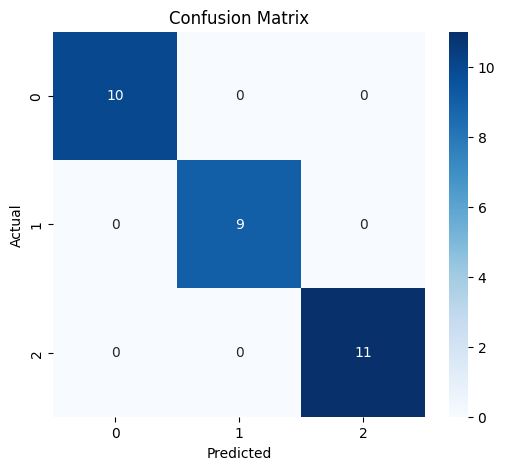

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Conclusion

Among the three machine learning models, Random Forest and KNN achieved the highest accuracy on the Iris dataset. Random Forest performed exceptionally well because it combines multiple decision trees and reduces overfitting. Logistic Regression also performed well but slightly lower compared to the other models. Overall, the models successfully classified iris flower species with very high accuracy.